In [1]:
import os
import sys

os.chdir("..")
sys.path.append("src")

In [2]:
import torch
import pandas as pd
import matplotlib.pyplot as plt

from wildfire_gnn.utils.config import load_yaml_config
from wildfire_gnn.pipelines.gnn_pipeline import GNNPipeline
from wildfire_gnn.features.feature_engineering import (
    add_degree_feature,
    add_neighborhood_summary_features,
)
from wildfire_gnn.data.graph_splitters import (
    attach_masks_from_split_file,
    print_mask_summary,
)

In [3]:
config = load_yaml_config("configs/gnn_config.yaml")
pipeline = GNNPipeline(config)

data = torch.load(
    config["paths"]["graph_data_path"],
    map_location="cpu",
    weights_only=False
)

data = attach_masks_from_split_file(
    data,
    config["paths"]["spatial_split_path"]
)

print(data)
print("x shape:", data.x.shape)
print("y shape:", data.y.shape)
print("edge_index shape:", data.edge_index.shape)
print_mask_summary(data)

Data(x=[300000, 7], edge_index=[2, 991684], y=[300000, 1], pos=[300000, 2], num_nodes_original_grid=3589100, num_valid_nodes_before_sampling=702972, num_valid_nodes=300000, reference_height=1900, reference_width=1889, target_name='Burn_Prob.img', feature_names=[7], train_mask=[300000], val_mask=[300000], test_mask=[300000])
x shape: torch.Size([300000, 7])
y shape: torch.Size([300000, 1])
edge_index shape: torch.Size([2, 991684])
Mask summary:
train: 199167
val  : 40718
test : 60115
total: 300000
nodes: 300000


In [4]:
# Save raw target for weighting + final evaluation
data.y_raw = data.y.clone()

# Apply training-time target transform
if config["data"].get("target_transform", "none") == "log1p":
    data.y = torch.log1p(data.y)

print("Target stats after training transform:")
print("min:", float(data.y.min()))
print("max:", float(data.y.max()))
print("raw max:", float(data.y_raw.max()))

Target stats after training transform:
min: 2.3405691536027007e-05
max: 0.2225854992866516
raw max: 0.24930262565612793


In [ ]:
if config["feature_engineering"].get("add_degree_feature", False):
    data = add_degree_feature(data)

if config["feature_engineering"].get("add_neighborhood_features", False):
    aggs = set(config["feature_engineering"].get("neighborhood_aggs", []))
    data = add_neighborhood_summary_features(
        data,
        add_mean=("mean" in aggs),
        add_std=("std" in aggs),
        add_max=("max" in aggs),
        add_residual=("residual" in aggs),
    )

print("Engineered x shape:", data.x.shape)

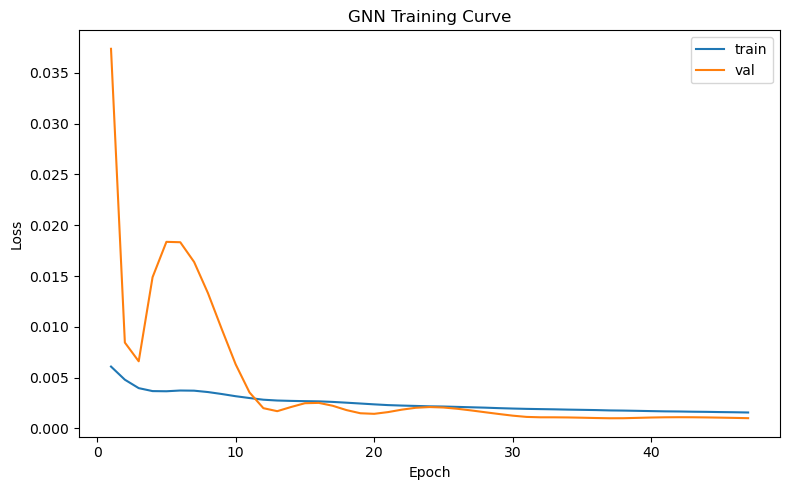

In [6]:
hist = train_outputs.history

plt.figure(figsize=(8, 5))
plt.plot(hist["epoch"], hist["train_loss"], label="train")
plt.plot(hist["epoch"], hist["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GNN Training Curve")
plt.legend()
plt.tight_layout()
plt.savefig("reports/figures/gnn_loss_curve.png", dpi=200)
plt.show()

In [7]:
metrics = pipeline.evaluate(
    data=data,
    checkpoint_path=train_outputs.best_model_path,
    stage="stage1",
)
metrics

{'rmse': 0.04021005346754276,
 'mae': 0.03528282046318054,
 'r2': -5.745616912841797,
 'pearson': 0.2116033136844635,
 'spearman': 0.2556657523263007}

In [8]:
pred_df = pd.read_csv("reports/tables/gnn_spatial_test_predictions.csv")
pred_df.head()

,y_true,y_pred,uncertainty
0,0.023607,0.060899,0.0
1,0.030925,0.038505,0.0
2,0.062656,0.036562,0.0
3,0.003133,0.053864,0.0
4,0.002632,0.035045,0.0


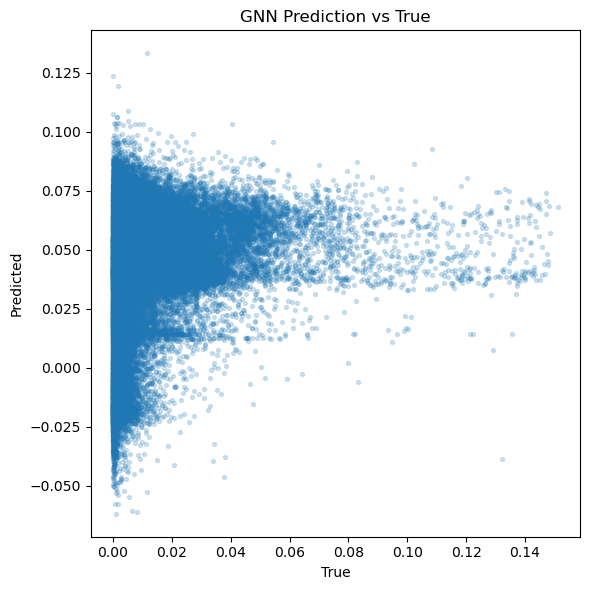

In [9]:
plt.figure(figsize=(6, 6))
plt.scatter(pred_df["y_true"], pred_df["y_pred"], alpha=0.2, s=8)
plt.xlabel("True")
plt.ylabel("Predicted")
plt.title("GNN Prediction vs True")
plt.tight_layout()
plt.savefig("reports/figures/gnn_pred_vs_true.png", dpi=200)
plt.show()